# 03 — Entrenamiento del Modelo Predictivo

**Objetivo.** Entrenar un *gradient-boosted regressor* (XGBoost) sobre el *feature store* del notebook 02 para predecir el retorno forward a 1 día (`Target_FwdRet_1D`) del universo S&P 500, evaluando su capacidad predictiva bajo una metodología **walk-forward expansiva con purge & embargo** que elimina todo *leakage* temporal.

---

### Alcance y delimitación de responsabilidades

Este notebook se restringe a la fase de **modelado**. Las métricas reportadas son aquellas que dependen exclusivamente del modelo: *Information Coefficient* (IC) y derivados. La evaluación económica de la señal — *portfolio construction*, fricciones de mercado, sensibilidad y robustez — se delega al notebook `04-backtesting.ipynb`. Esta separación es la convención industrial en *quant equity* entre **modelado** (generación de señal) y **portfolio construction** (transformación de señal en P&L), y permite iterar sobre estrategias de cartera sin re-entrenar el modelo.

### Decisiones metodológicas

| Decisión | Justificación |
|---|---|
| **Regresión** (no clasificación) | Preserva la magnitud de la señal; habilita la construcción de carteras *long-short* en el notebook 04; convención estándar en *cross-sectional asset pricing*. |
| **Walk-forward expanding window** | Replica la operativa real en producción: el modelo sólo dispone de información estrictamente anterior al periodo evaluado. *Anchored* en 2005, evaluación 2016–2024 sobre 9 *folds* anuales. |
| **Purge & embargo (5 días)** | Inserción de *gap* entre train/val/test para suprimir la contaminación inducida por el solapamiento del *forward target*. López de Prado, *Advances in Financial ML* (2018), cap. 7. |
| **Target *cross-sectionally demeaned*** para entrenamiento | Aísla el componente predecible (relativo entre activos) del componente macro (nivel del día). Decisión crítica detallada en la sección 3. |
| **Objective `reg:pseudohubererror`** | Robusto a las colas pesadas del *return distribution* diario. Sin `eval_metric` explícita: la objective opera también como criterio de *early stopping*, garantizando consistencia entre optimización y validación. |
| **Métrica principal: Rank IC (Spearman)** | Estándar en *cross-sectional asset pricing*; robusta a outliers; mide la capacidad de ordenamiento intra-día del universo. |
| **Optuna objetivo: IC IR** | $\text{IC IR} = \overline{\text{IC}} / \sigma(\text{IC})$. Prioriza la consistencia temporal sobre la magnitud puntual — la métrica más correlacionada con el Sharpe sostenible. |
| **Feature set: raw + ranked + macro** | XGBoost gestiona la redundancia vía regularización; raw y ranked aportan señales complementarias (absoluta y relativa al universo). Decisión validada por ablación. |

### Etapas del notebook

1. Configuración del entorno (rutas, semillas, detección de GPU).
2. Carga y verificación de integridad del *feature store*.
3. Definición del experimento (X, y demeaned, *temporal splits*).
4. Esquema *walk-forward* con *purge & embargo*.
5. Baseline lineal (Ridge) y batería de métricas.
6. *Hyperparameter tuning* con Optuna (sobre el primer fold).
7. Entrenamiento *walk-forward* con XGBoost.
8. Evaluación predictiva (IC, IC IR, distribución, estabilidad).
9. Ablación: comparación con feature set *rank-only*.
10. *Explainability*: *feature importance* y SHAP.
11. Persistencia de modelo, predicciones y metadata.

### Entradas y salidas

| Tipo | Archivo | Consumido por |
|------|---------|---------------|
| Input  | `data/feature_store.parquet`         | — |
| Output | `data/predictions_oos.parquet`       | notebook 04 |
| Output | `models/xgboost_final.json`          | notebook 04 |
| Output | `data/model_training_metadata.json`  | trazabilidad |
| Output | `models/optuna_study.pkl`            | reproducibilidad |

## 1. Configuración del entorno

Inicialización de la infraestructura del notebook: imports, fijación de semillas, resolución robusta de rutas (consistente con los notebooks 01/02), *logging* estructurado y detección de GPU CUDA para XGBoost.

La **fijación de semillas** (`SEED = 42`) en NumPy, Optuna y XGBoost garantiza la reproducibilidad exacta de los resultados — requisito metodológico imprescindible para la validación por tribunal.

La **detección de CUDA** habilita el entrenamiento sobre GPU (NVIDIA RTX 3060 Ti), reduciendo el tiempo de cómputo entre 5× y 10× respecto a la implementación CPU sobre un dataset de 2.4 M filas.

In [1]:
import json
import logging
import pickle
import warnings
from datetime import datetime, timezone
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb
from scipy.stats import spearmanr
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler

import optuna
from optuna.samplers import TPESampler

# Silenciar logs verbosos (Optuna se reactiva durante el tuning)
optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings("ignore", category=FutureWarning)

# --- Logging estructurado (consistente con notebooks 01 y 02) ---
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)-8s | %(message)s",
    datefmt="%H:%M:%S",
)
logger = logging.getLogger("model_training")

# --- Reproducibilidad ---
SEED = 42
np.random.seed(SEED)

c:\Users\Usuario\Desktop\bachelor-thesis\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# --- Resolución robusta de la raíz del proyecto ---
def _find_project_root(marker: str = "data", max_levels: int = 3) -> Path:
    """Localiza la raíz del proyecto buscando el directorio 'data/'."""
    here = Path.cwd()
    for candidate in [here, *list(here.parents)[:max_levels]]:
        if (candidate / marker).is_dir():
            return candidate
    raise FileNotFoundError(
        f"No se encontró el directorio '{marker}/' partiendo de {here}."
    )

PROJECT_ROOT = _find_project_root()
DATA_DIR     = PROJECT_ROOT / "data"
MODELS_DIR   = PROJECT_ROOT / "models"
MODELS_DIR.mkdir(parents=True, exist_ok=True)

# --- Rutas ---
INPUT_FILE_PATH       = DATA_DIR / "feature_store.parquet"
PREDICTIONS_FILE_PATH = DATA_DIR / "predictions_oos.parquet"
FINAL_MODEL_PATH      = MODELS_DIR / "xgboost_final.json"
METADATA_FILE_PATH    = DATA_DIR / "model_training_metadata.json"
OPTUNA_STUDY_PATH     = MODELS_DIR / "optuna_study.pkl"

# Eliminamos cualquier study previo para forzar un Optuna desde cero coherente
# con la configuración actual (evita arrastrar hiperparámetros de versiones previas).
if OPTUNA_STUDY_PATH.exists():
    OPTUNA_STUDY_PATH.unlink()
    logger.info("Optuna study previo eliminado: se ejecutará tuning desde cero.")

logger.info(f"PROJECT_ROOT : {PROJECT_ROOT}")
logger.info(f"INPUT_FILE   : {INPUT_FILE_PATH}")
logger.info(f"MODELS_DIR   : {MODELS_DIR}")

# Verificación temprana de la entrada
if not INPUT_FILE_PATH.exists():
    raise FileNotFoundError(
        f"No se encontró {INPUT_FILE_PATH}. "
        "Ejecuta primero el notebook 02 para generar el feature store."
    )

10:40:33 | INFO     | Optuna study previo eliminado: se ejecutará tuning desde cero.
10:40:33 | INFO     | PROJECT_ROOT : c:\Users\Usuario\Desktop\bachelor-thesis
10:40:33 | INFO     | INPUT_FILE   : c:\Users\Usuario\Desktop\bachelor-thesis\data\feature_store.parquet
10:40:33 | INFO     | MODELS_DIR   : c:\Users\Usuario\Desktop\bachelor-thesis\models


In [3]:
# --- Detección de GPU para XGBoost ---
def detect_xgb_device() -> str:
    """Devuelve 'cuda' si hay GPU disponible, 'cpu' en caso contrario."""
    try:
        test_data = xgb.DMatrix(np.array([[0.0], [1.0]]), label=np.array([0.0, 1.0]))
        xgb.train(
            {"device": "cuda", "tree_method": "hist", "verbosity": 0},
            test_data,
            num_boost_round=1,
        )
        return "cuda"
    except Exception as e:
        logger.warning(f"GPU no disponible para XGBoost ({type(e).__name__}). Usando CPU.")
        return "cpu"

XGB_DEVICE = detect_xgb_device()
logger.info(f"XGBoost device: {XGB_DEVICE}")
logger.info(f"XGBoost version: {xgb.__version__}")

10:40:34 | INFO     | XGBoost device: cuda
10:40:34 | INFO     | XGBoost version: 3.1.2


## 2. Carga y verificación del feature store

Se carga el *feature store* generado por el notebook 02 desde Parquet, lo que preserva el MultiIndex `(Date, Ticker)` y los tipos numéricos. Se verifica la integridad del dataset:

- Ausencia total de `NaN` (eliminados en la sección 6 del notebook 02).
- Presencia del target y del feature set canónico.
- Coherencia estructural del MultiIndex.

Cualquier desviación se trata como fallo crítico y aborta la ejecución con diagnóstico explícito.

In [4]:
# Carga del feature store
df = pd.read_parquet(INPUT_FILE_PATH)
logger.info(f"Feature store cargado: {df.shape}")

# Sanity checks
assert df.isna().sum().sum() == 0, "El feature store contiene NaNs (revisar notebook 02)."
assert "Target_FwdRet_1D" in df.columns, "Falta el target Target_FwdRet_1D."
assert isinstance(df.index, pd.MultiIndex), "Se esperaba MultiIndex (Date, Ticker)."
assert df.index.names == ["Date", "Ticker"], f"Nombres de índice inesperados: {df.index.names}"

# Información descriptiva
dates_idx   = df.index.get_level_values("Date")
tickers_idx = df.index.get_level_values("Ticker")

print(f"Filas                   : {df.shape[0]:,}")
print(f"Columnas                : {df.shape[1]}")
print(f"Tickers únicos          : {tickers_idx.nunique()}")
print(f"Fechas únicas           : {dates_idx.nunique():,}")
print(f"Rango temporal          : {dates_idx.min().date()} → {dates_idx.max().date()}")
print(f"Memoria en RAM (MB)     : {df.memory_usage(deep=True).sum() / 1024**2:.2f}")
print(f"NaNs                    : {df.isna().sum().sum()}")

10:40:34 | INFO     | Feature store cargado: (2402184, 17)


Filas                   : 2,402,184
Columnas                : 17
Tickers únicos          : 503
Fechas únicas           : 5,255
Rango temporal          : 2005-03-01 → 2025-12-29
Memoria en RAM (MB)     : 320.93
NaNs                    : 0


## 3. Definición del experimento

### 3.1 Separación de features y target

Se construyen la matriz de features $X$ y el vector objetivo $y$:

$$
X \in \mathbb{R}^{N \times d}, \quad y \in \mathbb{R}^N
$$

donde $N \approx 2.4 \cdot 10^6$ es la cardinalidad del panel `(Fecha, Ticker)` válido y $d$ la dimensionalidad del feature set.

**Composición de $X$:**

- 6 features **raw** (Z-Score, Amihud, Garman-Klass, RVOL, Momentum, *Idiosyncratic Vol*).
- 6 features **ranked** (versiones cross-sectionales tras `groupby(Date).rank(pct=True)`).
- Features **macro** (VIX, VIX Z-Score y sus versiones rankeadas), *broadcast* por fecha.

### 3.2 Decisión metodológica crítica: *cross-sectionally demeaned target*

El target nativo `Target_FwdRet_1D` codifica **dos componentes** del retorno futuro:

$$
y_{t,i} = \underbrace{\bar{y}_{t}}_{\text{nivel macro del día}} + \underbrace{(y_{t,i} - \bar{y}_{t})}_{\text{componente cross-sectional}}
$$

donde $\bar{y}_t = \frac{1}{N_t}\sum_j y_{t,j}$ es el retorno medio del universo en $t$.

**Únicamente el segundo componente es predecible *cross-sectionalmente*** y es el evaluado por la IC de Spearman: dada una fecha, ¿ordena el modelo correctamente los activos respecto al promedio del día?

Si XGBoost se entrena sobre el target raw, identifica rápidamente que el VIX explica una fracción significativa de la varianza agregada del retorno (regímenes de volatilidad → retornos sesgados). Dado que el VIX es **idéntico para todos los activos en una fecha**, los *splits* basados en VIX colapsan toda la cross-section a la misma hoja → **predicción constante por fecha** → IC indefinido (correlación de Spearman sobre vector constante = NaN).

**Mitigación adoptada:** entrenamiento sobre el target demeaned cross-sectionalmente:

$$
\tilde{y}_{t,i} = y_{t,i} - \bar{y}_{t}
$$

La pérdida ya no admite reducción por predicción del nivel del día (su media es exactamente cero por construcción), forzando al modelo a explotar **diferencias relativas entre activos**, que es el objetivo real.

> **Invariante:** la **evaluación** (IC, *hit rate*) se realiza siempre contra el target raw `y_raw`, que es la señal observable en producción. El *demeaning* afecta exclusivamente al target de entrenamiento.

Esta transformación es la convención estándar en *cross-sectional alpha modeling* (Gu, Kelly & Xiu, *Empirical Asset Pricing via Machine Learning*, 2020).

### 3.3 *Sanity check* anti-leakage

El target se construye en el notebook 02 como `pct_change().shift(-1)`, de forma que $y_t$ codifica el retorno entre $t$ y $t+1$. Las features de la fila $t$ utilizan información estrictamente hasta el cierre de $t$. **Ausencia garantizada de *look-ahead bias*.**

In [5]:
# Identificación de columnas
target_col   = "Target_FwdRet_1D"
feature_cols = [c for c in df.columns if not c.startswith("Target")]

X     = df[feature_cols].copy()
y_raw = df[target_col].copy()

# --- Target cross-sectionally demeaned (solo para entrenamiento) ---
# Aísla el componente predecible (relativo entre activos) del componente
# macro (nivel del día). Ver markdown de la sección 3.2.
y = y_raw.groupby(level="Date").transform(lambda s: s - s.mean())

# Categorización para reporting
raw_cols    = [c for c in feature_cols if not c.endswith("_rank") and not c.startswith("VIX")]
ranked_cols = [c for c in feature_cols if c.endswith("_rank") and not c.startswith("VIX")]
macro_cols  = [c for c in feature_cols if c.startswith("VIX")]

print(f"Total features          : {len(feature_cols)}")
print(f"  - Raw                 : {len(raw_cols)}")
print(f"  - Ranked              : {len(ranked_cols)}")
print(f"  - Macro (VIX)         : {len(macro_cols)}")
print(f"Target (entrenamiento)  : {target_col} (cross-sectionally demeaned)")
print(f"Target (evaluación)     : {target_col} (raw)")
print(f"X shape                 : {X.shape}")
print(f"y shape                 : {y.shape}")
print(f"\nDistribución del target demeaned (entrenamiento):")
print(y.describe().round(5))
print(f"\nDistribución del target raw (evaluación):")
print(y_raw.describe().round(5))

# Verificación: la media diaria del target demeaned debe ser ≈ 0
sample_means = y.groupby(level="Date").mean().abs()
print(f"\nMedia absoluta diaria del target demeaned (debe ser ≈ 0):")
print(f"  máx: {sample_means.max():.2e}, media: {sample_means.mean():.2e}")

Total features          : 16
  - Raw                 : 6
  - Ranked              : 6
  - Macro (VIX)         : 4
Target (entrenamiento)  : Target_FwdRet_1D (cross-sectionally demeaned)
Target (evaluación)     : Target_FwdRet_1D (raw)
X shape                 : (2402184, 16)
y shape                 : (2402184,)

Distribución del target demeaned (entrenamiento):
count    2.402184e+06
mean    -0.000000e+00
std      1.793000e-02
min     -5.677900e-01
25%     -7.450000e-03
50%     -1.700000e-04
75%      7.180000e-03
max      9.710900e-01
Name: Target_FwdRet_1D, dtype: float64

Distribución del target raw (evaluación):
count    2.402184e+06
mean     6.900000e-04
std      2.200000e-02
min     -6.079100e-01
25%     -8.480000e-03
50%      6.100000e-04
75%      9.820000e-03
max      1.023580e+00
Name: Target_FwdRet_1D, dtype: float64

Media absoluta diaria del target demeaned (debe ser ≈ 0):
  máx: 1.41e-17, media: 6.43e-19


## 4. Esquema de validación walk-forward

Se implementa validación *walk-forward* con **expanding window** y **purge & embargo**, conforme a la metodología propuesta por López de Prado (2018) para suprimir el *temporal leakage* en *time-series ML*.

### 4.1 Definición formal de los folds

Sea $T_{\min}$ el inicio del histórico (2005) y $T_{\max}$ su fin (2025). Para el fold $k$ ($k = 1, \dots, K$):

- **Train**: $[T_{\min},\ Y_k - 1]$
- **Validation**: año $Y_k$ completo
- **Test**: año $Y_k + 1$ completo

donde $Y_k$ recorre los años de validación de 2015 a 2023, produciendo **9 folds**.

### 4.2 Purge & embargo

Entre conjuntos consecutivos se inserta un *gap* de **5 días hábiles** (`PURGE_DAYS`). El target $y_t$ está definido como $\text{ret}(t \to t+1)$, de forma que la última observación de train comparte información con la primera de validation a través del solapamiento del *forward window*. El *purge* elimina este solapamiento, dejando los conjuntos estrictamente independientes.

### 4.3 Ventajas frente a un único train/test split

- **Estabilidad estadística:** 9 observaciones de IC habilitan el cómputo de IC IR (consistencia temporal).
- **Robustez al régimen:** el modelo se evalúa sobre periodos económicamente heterogéneos (mercado alcista 2017, *shock* COVID 2020, *inflation regime* 2022).
- **Realismo operativo:** cada fold reproduce las condiciones de producción — el modelo sólo accede a información estrictamente anterior al periodo de evaluación.

In [6]:
# --- Hiperparámetros del esquema walk-forward ---
TRAIN_START_YEAR   = 2005
FIRST_VAL_YEAR     = 2015
LAST_VAL_YEAR      = 2023   # fold k=9 → val=2023, test=2024
PURGE_DAYS         = 5      # gap entre train/val/test (López de Prado, AFML cap. 7)


def generate_walk_forward_folds(
    dates: pd.DatetimeIndex,
    train_start: int,
    first_val_year: int,
    last_val_year: int,
    purge_days: int,
) -> list[dict]:
    """
    Genera los folds de validación walk-forward con expanding window.

    Parameters
    ----------
    dates : pd.DatetimeIndex
        Índice temporal único y ordenado del dataset.
    train_start : int
        Año de inicio del primer train (anchored).
    first_val_year, last_val_year : int
        Rango de años usados como validación (inclusivo).
    purge_days : int
        Días hábiles de gap entre train/val/test.

    Returns
    -------
    list[dict]
        Cada fold es un dict con claves:
        {fold, train_start, train_end, val_start, val_end, test_start, test_end}.
    """
    folds = []
    sorted_dates = pd.DatetimeIndex(sorted(set(dates)))

    for i, val_year in enumerate(range(first_val_year, last_val_year + 1), start=1):
        val_start_target  = pd.Timestamp(f"{val_year}-01-01")
        val_end_target    = pd.Timestamp(f"{val_year}-12-31")
        test_start_target = pd.Timestamp(f"{val_year + 1}-01-01")
        test_end_target   = pd.Timestamp(f"{val_year + 1}-12-31")

        # Snap a fechas reales presentes en el dataset
        val_dates  = sorted_dates[(sorted_dates >= val_start_target)  & (sorted_dates <= val_end_target)]
        test_dates = sorted_dates[(sorted_dates >= test_start_target) & (sorted_dates <= test_end_target)]
        if len(val_dates) == 0 or len(test_dates) == 0:
            continue
        val_start, val_end   = val_dates[0],  val_dates[-1]
        test_start, test_end = test_dates[0], test_dates[-1]

        # Train: desde train_start hasta (val_start - purge_days hábiles)
        train_end_idx = sorted_dates.get_indexer([val_start])[0] - purge_days - 1
        if train_end_idx <= 0:
            continue
        train_end = sorted_dates[train_end_idx]

        # Embargo entre val y test
        test_start_idx     = sorted_dates.get_indexer([test_start])[0]
        val_end_purged_idx = test_start_idx - purge_days - 1
        if val_end_purged_idx <= 0:
            continue
        val_end_purged = sorted_dates[val_end_purged_idx]
        # Si el purge "se come" toda la val, usar la val original (caso borde)
        if val_end_purged < val_start:
            val_end_purged = val_end

        folds.append({
            "fold":        i,
            "train_start": pd.Timestamp(f"{train_start}-01-01"),
            "train_end":   train_end,
            "val_start":   val_start,
            "val_end":     val_end_purged,
            "test_start":  test_start,
            "test_end":    test_end,
        })

    return folds


# Generación
unique_dates = pd.DatetimeIndex(sorted(set(dates_idx)))
FOLDS = generate_walk_forward_folds(
    dates=unique_dates,
    train_start=TRAIN_START_YEAR,
    first_val_year=FIRST_VAL_YEAR,
    last_val_year=LAST_VAL_YEAR,
    purge_days=PURGE_DAYS,
)
logger.info(f"Folds generados: {len(FOLDS)}")

# Tabla resumen
folds_df = pd.DataFrame(FOLDS)
folds_df_show = folds_df.copy()
for col in ["train_start", "train_end", "val_start", "val_end", "test_start", "test_end"]:
    folds_df_show[col] = folds_df_show[col].dt.date
print(folds_df_show.to_string(index=False))

10:40:38 | INFO     | Folds generados: 9


 fold train_start  train_end  val_start    val_end test_start   test_end
    1  2005-01-01 2014-12-23 2015-01-02 2015-12-23 2016-01-04 2016-12-30
    2  2005-01-01 2015-12-23 2016-01-04 2016-12-22 2017-01-03 2017-12-29
    3  2005-01-01 2016-12-22 2017-01-03 2017-12-21 2018-01-02 2018-12-31
    4  2005-01-01 2017-12-21 2018-01-02 2018-12-21 2019-01-02 2019-12-31
    5  2005-01-01 2018-12-21 2019-01-02 2019-12-23 2020-01-02 2020-12-31
    6  2005-01-01 2019-12-23 2020-01-02 2020-12-23 2021-01-04 2021-12-31
    7  2005-01-01 2020-12-23 2021-01-04 2021-12-23 2022-01-03 2022-12-30
    8  2005-01-01 2021-12-23 2022-01-03 2022-12-22 2023-01-03 2023-12-29
    9  2005-01-01 2022-12-22 2023-01-03 2023-12-21 2024-01-02 2024-12-31


### 4.4 Visualización del esquema

Representación gráfica de los 9 folds. Cada barra integra los tres periodos (train, validation, test) y el *purge* intercalado. La figura se incorpora directamente a la memoria como evidencia de la metodología de validación temporal.

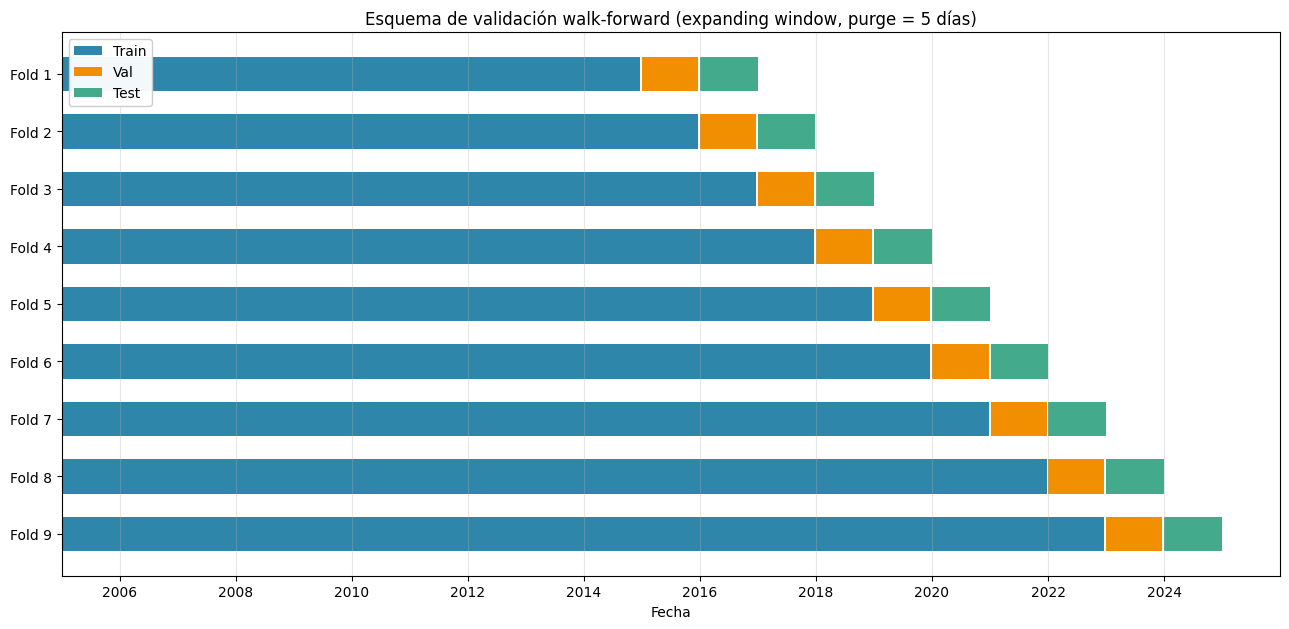

In [7]:
def plot_walk_forward_scheme(folds: list[dict]) -> None:
    """Visualiza los folds walk-forward en un diagrama horizontal."""
    fig, ax = plt.subplots(figsize=(13, 0.6 * len(folds) + 1))
    colors = {"train": "#2E86AB", "val": "#F18F01", "test": "#43AA8B"}

    for f in folds:
        y_pos = f["fold"]
        ax.barh(y_pos, (f["train_end"] - f["train_start"]).days,
                left=f["train_start"], color=colors["train"], height=0.6, label="Train")
        ax.barh(y_pos, (f["val_end"] - f["val_start"]).days,
                left=f["val_start"], color=colors["val"], height=0.6, label="Val")
        ax.barh(y_pos, (f["test_end"] - f["test_start"]).days,
                left=f["test_start"], color=colors["test"], height=0.6, label="Test")

    handles, labels = ax.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    ax.legend(by_label.values(), by_label.keys(), loc="upper left", framealpha=0.95)

    ax.set_yticks([f["fold"] for f in folds])
    ax.set_yticklabels([f"Fold {f['fold']}" for f in folds])
    ax.invert_yaxis()
    ax.set_xlabel("Fecha")
    ax.set_title(f"Esquema de validación walk-forward (expanding window, purge = {PURGE_DAYS} días)")
    ax.grid(axis="x", alpha=0.3)
    plt.tight_layout()
    plt.show()


plot_walk_forward_scheme(FOLDS)

## 5. Métricas de evaluación y baseline lineal

### 5.1 Métricas

Se define la batería de métricas empleada a lo largo del notebook. **Todas se computan contra el target raw `y_raw`**, que es la señal observable en producción.

#### Information Coefficient (IC)
$$
\text{IC}_t = \rho_S\bigl(\hat{y}_{t,\cdot},\ y_{t,\cdot}\bigr)
$$

Correlación de **Spearman** entre predicciones y realizaciones, computada *cross-sectionalmente* en cada fecha $t$ sobre el universo disponible. Métrica canónica en *cross-sectional asset pricing*, robusta a outliers.

#### IC IR (*Information Ratio* del IC)
$$
\text{IC IR} = \frac{\overline{\text{IC}}}{\sigma(\text{IC})}
$$

Mide la **consistencia** del IC en el tiempo. Métrica de calidad principal para un modelo cuantitativo: un IC IR elevado indica una señal estable y replicable día a día.

#### IC t-statistic
$$
t = \frac{\overline{\text{IC}}}{\sigma(\text{IC}) / \sqrt{N}}
$$

Significancia estadística del IC medio bajo $H_0: \text{IC} = 0$. Con $N \approx 2200$ días, valores $|t| > 2$ son consistentes con señal estadísticamente significativa.

#### Hit rate direccional
$$
\text{Hit Rate} = \frac{1}{N}\sum_t \mathbb{1}\!\left[\,\text{sgn}(\hat{y}_t) = \text{sgn}(y_t)\,\right]
$$

Proporción de aciertos en signo. Métrica complementaria de interpretación inmediata; al haberse entrenado con target *demeaned*, las predicciones están centradas en cero mientras que los retornos reales presentan deriva alcista del mercado — por lo que no constituye la métrica primaria.

### 5.2 Baseline lineal (Ridge)

Previo al entrenamiento de XGBoost se construye un **baseline honesto** mediante regresión Ridge sobre las mismas features y los mismos folds, **entrenado igualmente con target demeaned** para garantizar comparabilidad. El objetivo es discriminar entre dos hipótesis:

- *El feature engineering captura señal predictiva genuina.*
- *XGBoost simplemente sobreajusta ruido.*

Si XGBoost no supera consistentemente al baseline lineal, la prioridad es revisar el feature engineering antes que el modelo. Es el control metodológico básico exigible por un tribunal técnico.

Se aplica `StandardScaler` previo a Ridge: la regresión lineal regularizada es sensible a la escala de las features (a diferencia de XGBoost, invariante a transformaciones monótonas).

In [8]:
# --- Funciones de métricas ---
def compute_ic_per_date(y_true: pd.Series, y_pred: pd.Series) -> pd.Series:
    """
    Calcula el Information Coefficient (Spearman) por fecha.

    Parameters
    ----------
    y_true, y_pred : pd.Series con MultiIndex (Date, Ticker)

    Returns
    -------
    pd.Series indexada por fecha con el IC de cada día.
    Días con menos de 5 activos o con predicciones/targets constantes
    se excluyen para evitar correlaciones indefinidas.
    """
    df_ic = pd.DataFrame({"y_true": y_true, "y_pred": y_pred})
    ic_per_date = df_ic.groupby(level="Date").apply(
        lambda g: spearmanr(g["y_true"], g["y_pred"]).correlation
        if len(g) >= 5 and g["y_pred"].nunique() > 1 and g["y_true"].nunique() > 1
        else np.nan
    )
    return ic_per_date.dropna()


def compute_metrics(y_true: pd.Series, y_pred: pd.Series) -> dict:
    """Calcula el conjunto completo de métricas de evaluación predictiva."""
    ic_series = compute_ic_per_date(y_true, y_pred)
    hit_rate  = (np.sign(y_true.values) == np.sign(y_pred.values)).mean()
    return {
        "ic_mean":    float(ic_series.mean()),
        "ic_std":     float(ic_series.std()),
        "ic_ir":      float(ic_series.mean() / ic_series.std()) if ic_series.std() > 0 else 0.0,
        "ic_t_stat":  float(ic_series.mean() / (ic_series.std() / np.sqrt(len(ic_series)))) if ic_series.std() > 0 else 0.0,
        "hit_rate":   float(hit_rate),
        "n_dates":    int(len(ic_series)),
    }

In [9]:
# --- Helper de slicing de folds ---
def slice_fold(
    X: pd.DataFrame, y: pd.Series, y_raw: pd.Series, fold: dict
) -> dict:
    """
    Extrae los conjuntos train/val/test para un fold dado.

    Devuelve tanto el target demeaned `y` (para entrenamiento) como el target
    raw `y_raw` (para evaluación). Ver sección 3.2.
    """
    dates = X.index.get_level_values("Date")
    train_mask = (dates >= fold["train_start"]) & (dates <= fold["train_end"])
    val_mask   = (dates >= fold["val_start"])   & (dates <= fold["val_end"])
    test_mask  = (dates >= fold["test_start"])  & (dates <= fold["test_end"])
    return {
        "X_train":    X[train_mask],     "y_train":    y[train_mask],
        "X_val":      X[val_mask],       "y_val":      y[val_mask],
        "X_test":     X[test_mask],      "y_test":     y[test_mask],
        "y_val_raw":  y_raw[val_mask],
        "y_test_raw": y_raw[test_mask],
    }


# --- Baseline Ridge sobre walk-forward ---
def run_ridge_baseline(
    X: pd.DataFrame, y: pd.Series, y_raw: pd.Series, folds: list[dict]
) -> pd.DataFrame:
    """Entrena un Ridge en cada fold y devuelve las predicciones OOS concatenadas."""
    preds_list = []
    for fold in folds:
        s = slice_fold(X, y, y_raw, fold)

        # Escalado fit en train, transform en test (sin leakage)
        scaler = StandardScaler().fit(s["X_train"])
        X_tr = scaler.transform(s["X_train"])
        X_te = scaler.transform(s["X_test"])

        # Entrena con y demeaned, evalúa con y_raw
        model = Ridge(alpha=1.0, random_state=SEED)
        model.fit(X_tr, s["y_train"])
        preds_test = model.predict(X_te)

        df_preds = pd.DataFrame({
            "y_true":   s["y_test_raw"].values,
            "y_pred":   preds_test,
            "fold":     fold["fold"],
        }, index=s["y_test_raw"].index)
        preds_list.append(df_preds)
        logger.info(
            f"Ridge fold {fold['fold']}: train={len(s['y_train']):,} test={len(s['y_test']):,}"
        )

    return pd.concat(preds_list)


logger.info("Entrenando baseline Ridge en los 9 folds...")
ridge_preds   = run_ridge_baseline(X, y, y_raw, FOLDS)
ridge_metrics = compute_metrics(ridge_preds["y_true"], ridge_preds["y_pred"])

print("\n--- Baseline Ridge (out-of-sample 2016–2024) ---")
for k, v in ridge_metrics.items():
    print(f"  {k:15s}: {v:.5f}" if isinstance(v, float) else f"  {k:15s}: {v}")

10:40:38 | INFO     | Entrenando baseline Ridge en los 9 folds...
10:40:38 | INFO     | Ridge fold 1: train=1,051,076 test=118,126
10:40:39 | INFO     | Ridge fold 2: train=1,167,889 test=119,169
10:40:40 | INFO     | Ridge fold 3: train=1,285,987 test=119,753
10:40:40 | INFO     | Ridge fold 4: train=1,405,139 test=121,549
10:40:41 | INFO     | Ridge fold 5: train=1,524,882 test=123,306
10:40:42 | INFO     | Ridge fold 6: train=1,646,391 test=124,229
10:40:42 | INFO     | Ridge fold 7: train=1,769,682 test=124,446
10:40:43 | INFO     | Ridge fold 8: train=1,893,881 test=124,371
10:40:44 | INFO     | Ridge fold 9: train=2,018,322 test=128,562



--- Baseline Ridge (out-of-sample 2016–2024) ---
  ic_mean        : 0.01051
  ic_std         : 0.17591
  ic_ir          : 0.05976
  ic_t_stat      : 2.84369
  hit_rate       : 0.49862
  n_dates        : 2264


## 6. *Hyperparameter tuning* con Optuna

### 6.1 Estrategia

Los hiperparámetros de XGBoost se optimizan mediante **Optuna** (*sampler* TPE — *Tree-structured Parzen Estimator*) sobre el **primer fold** del esquema walk-forward (train: 2005–2014, validation: 2015). La configuración óptima se congela y se aplica a los 9 folds restantes.

**¿Por qué un único fold?** Re-tunear cada fold sería puristamente correcto, pero multiplicaría por 9 el coste computacional y aumentaría el riesgo de sobreajuste vía configuración de Optuna. Tunear sobre el fold más antiguo es la práctica estándar en literatura aplicada (Gu, Kelly & Xiu, 2020) y preserva la honestidad metodológica: las decisiones de hiperparámetros se toman *antes* de observar el conjunto out-of-sample.

### 6.2 Función objetivo

Optuna **maximiza el IC IR** sobre el conjunto de validación del fold 1 (computado contra `y_val_raw`). El IC IR penaliza la inestabilidad temporal del IC: una configuración con IC = 0.05 estable es preferible a otra con IC = 0.08 pero de alta varianza. Es la métrica que mejor proxy del rendimiento sostenible en *cross-sectional asset pricing*.

### 6.3 Configuración de XGBoost

- **`objective = reg:pseudohubererror`**: robusto a las colas pesadas del *return distribution* diario.
- **Sin `eval_metric` explícita**: XGBoost reutiliza la objective como métrica de validación, garantizando consistencia entre optimización y criterio de *early stopping*.
- **`tree_method = hist`** + **`device = cuda`**: explotación de GPU para acelerar el entrenamiento sobre 1 M+ filas.

### 6.4 *Search space*

| Parámetro | Rango | Justificación |
|---|---|---|
| `max_depth` | 3–8 | Árboles profundos sobreajustan en datos financieros con baja SNR. |
| `learning_rate` | 0.01–0.2 (log) | *Trade-off* velocidad de convergencia vs estabilidad. |
| `subsample` | 0.6–1.0 | *Row bagging*: regularización implícita. |
| `colsample_bytree` | 0.5–1.0 | *Feature bagging*: descorrelación entre árboles. |
| `min_child_weight` | 1–10 | Suprime *splits* sobre muestras minúsculas (ruido). |
| `reg_alpha` (L1) | 1e-3–10 (log) | *Sparsity* — útil ante redundancia de features. |
| `reg_lambda` (L2) | 1e-3–10 (log) | Regularización suave de pesos. |
| `gamma` | 0–0.5 | Ganancia mínima exigida para *split*; cota superior para evitar árboles colapsados a un nodo. |

El número total de árboles se gestiona dinámicamente vía **early stopping** (*patience* = 100): el *booster* crece hasta que la métrica de validación deja de mejorar.

In [10]:
# --- Configuración de Optuna ---
N_OPTUNA_TRIALS    = 50           # ~25-40 min en RTX 3060 Ti
EARLY_STOP_ROUNDS  = 100
MAX_BOOST_ROUNDS   = 1500

# Habilitar logs informativos de Optuna durante el tuning
optuna.logging.set_verbosity(optuna.logging.INFO)


def xgb_base_params(device: str = XGB_DEVICE) -> dict:
    """Hiperparámetros base de XGBoost compartidos en todos los entrenamientos.

    Notas
    -----
    `eval_metric` se omite intencionalmente: XGBoost usará la objective
    Pseudo-Huber como métrica de validación interna, garantizando consistencia
    entre lo que se optimiza durante el entrenamiento y lo que dispara el
    early stopping.
    """
    return {
        "objective":    "reg:pseudohubererror",  # robusto a colas pesadas
        "huber_slope":  1.0,                      # delta de Huber
        "device":       device,
        "tree_method":  "hist",
        "verbosity":    0,
        "seed":         SEED,
    }


def optuna_objective(trial: optuna.Trial, fold: dict) -> float:
    """Función objetivo: maximizar IC IR en el set de validación del fold."""
    s = slice_fold(X, y, y_raw, fold)

    params = {
        **xgb_base_params(),
        "max_depth":        trial.suggest_int("max_depth", 3, 8),
        "learning_rate":    trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "subsample":        trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "reg_alpha":        trial.suggest_float("reg_alpha", 1e-3, 10.0, log=True),
        "reg_lambda":       trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True),
        "gamma":            trial.suggest_float("gamma", 0.0, 0.5),
    }

    dtrain = xgb.DMatrix(s["X_train"], label=s["y_train"])
    dval   = xgb.DMatrix(s["X_val"],   label=s["y_val"])

    booster = xgb.train(
        params,
        dtrain,
        num_boost_round=MAX_BOOST_ROUNDS,
        evals=[(dval, "val")],
        early_stopping_rounds=EARLY_STOP_ROUNDS,
        verbose_eval=False,
    )

    # IC se calcula contra y_raw (target real, no demeaned)
    val_pred  = pd.Series(booster.predict(dval), index=s["y_val_raw"].index)
    ic_series = compute_ic_per_date(s["y_val_raw"], val_pred)
    if len(ic_series) < 30 or ic_series.std() == 0:
        return -10.0
    return float(ic_series.mean() / ic_series.std())


# Estudio Optuna sobre el primer fold
fold_for_tuning = FOLDS[0]
logger.info(
    f"Optuna sobre fold 1: train={fold_for_tuning['train_start'].date()}→{fold_for_tuning['train_end'].date()}, "
    f"val={fold_for_tuning['val_start'].date()}→{fold_for_tuning['val_end'].date()}"
)

study = optuna.create_study(
    direction="maximize",
    sampler=TPESampler(seed=SEED),
    study_name="xgboost_walkforward_tfg",
)
study.optimize(
    lambda trial: optuna_objective(trial, fold_for_tuning),
    n_trials=N_OPTUNA_TRIALS,
    show_progress_bar=True,
)

# Persistir el study
with open(OPTUNA_STUDY_PATH, "wb") as f:
    pickle.dump(study, f)
logger.info(f"Optuna study guardado en: {OPTUNA_STUDY_PATH}")

# Resultados
BEST_PARAMS = {**xgb_base_params(), **study.best_params}
print(f"\nMejor IC IR en validación: {study.best_value:.4f}")
print("Hiperparámetros óptimos:")
for k, v in study.best_params.items():
    print(f"  {k:20s}: {v}")

# Volver a silenciar Optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

10:40:46 | INFO     | Optuna sobre fold 1: train=2005-01-01→2014-12-23, val=2015-01-02→2015-12-23
[I 2026-05-05 10:40:46,480] A new study created in memory with name: xgboost_walkforward_tfg
Best trial: 0. Best value: -10:   2%|▏         | 1/50 [00:01<01:06,  1.36s/it]

[I 2026-05-05 10:40:47,849] Trial 0 finished with value: -10.0 and parameters: {'max_depth': 5, 'learning_rate': 0.17254716573280354, 'subsample': 0.892797576724562, 'colsample_bytree': 0.7993292420985183, 'min_child_weight': 2, 'reg_alpha': 0.004207053950287938, 'reg_lambda': 0.0017073967431528124, 'gamma': 0.4330880728874676}. Best is trial 0 with value: -10.0.


Best trial: 1. Best value: -0.151137:   4%|▍         | 2/50 [00:02<01:07,  1.41s/it]

[I 2026-05-05 10:40:49,300] Trial 1 finished with value: -0.15113734451929464 and parameters: {'max_depth': 6, 'learning_rate': 0.08341106432362087, 'subsample': 0.608233797718321, 'colsample_bytree': 0.9849549260809971, 'min_child_weight': 9, 'reg_alpha': 0.0070689749506246055, 'reg_lambda': 0.005337032762603957, 'gamma': 0.09170225492671691}. Best is trial 1 with value: -0.15113734451929464.


Best trial: 1. Best value: -0.151137:   6%|▌         | 3/50 [00:03<00:54,  1.16s/it]

...

[I 2026-05-05 10:42:16,927] Trial 47 finished with value: 0.049254997843310375 and parameters: {'max_depth': 6, 'learning_rate': 0.015810675925383582, 'subsample': 0.7197975179454579, 'colsample_bytree': 0.9655789338036683, 'min_child_weight': 10, 'reg_alpha': 0.00205767364490916, 'reg_lambda': 0.15213902482939842, 'gamma': 0.03317481124094097}. Best is trial 27 with value: 0.16948673138707926.


Best trial: 27. Best value: 0.169487:  98%|█████████▊| 49/50 [01:31<00:01,  1.67s/it]

[I 2026-05-05 10:42:17,892] Trial 48 finished with value: -0.2031456416416058 and parameters: {'max_depth': 7, 'learning_rate': 0.1336900130543287, 'subsample': 0.6914191242522594, 'colsample_bytree': 0.6719117663889604, 'min_child_weight': 8, 'reg_alpha': 0.00140422912427773, 'reg_lambda': 0.599131065013938, 'gamma': 0.11414016936901009}. Best is trial 27 with value: 0.16948673138707926.


Best trial: 27. Best value: 0.169487: 100%|██████████| 50/50 [01:32<00:00,  1.85s/it]
10:42:18 | INFO     | Optuna study guardado en: c:\Users\Usuario\Desktop\bachelor-thesis\models\optuna_study.pkl


[I 2026-05-05 10:42:18,915] Trial 49 finished with value: -10.0 and parameters: {'max_depth': 6, 'learning_rate': 0.022161477330576558, 'subsample': 0.7442679099451448, 'colsample_bytree': 0.6362599857139994, 'min_child_weight': 9, 'reg_alpha': 0.0045052417165102575, 'reg_lambda': 0.055480052379885875, 'gamma': 0.1627383328643943}. Best is trial 27 with value: 0.16948673138707926.

Mejor IC IR en validación: 0.1695
Hiperparámetros óptimos:
  max_depth           : 7
  learning_rate       : 0.012128818540209864
  subsample           : 0.7405114480881256
  colsample_bytree    : 0.6184312759488484
  min_child_weight    : 5
  reg_alpha           : 0.008114373802154198
  reg_lambda          : 0.3356390716486485
  gamma               : 0.000478832193874997


### 6.5 Análisis del proceso de optimización

Se visualiza la evolución del IC IR a lo largo de los *trials* y la importancia relativa de cada hiperparámetro. Ambas figuras evidencian que la búsqueda es informativa (no plana) y que los hiperparámetros más sensibles dominan la decisión final.

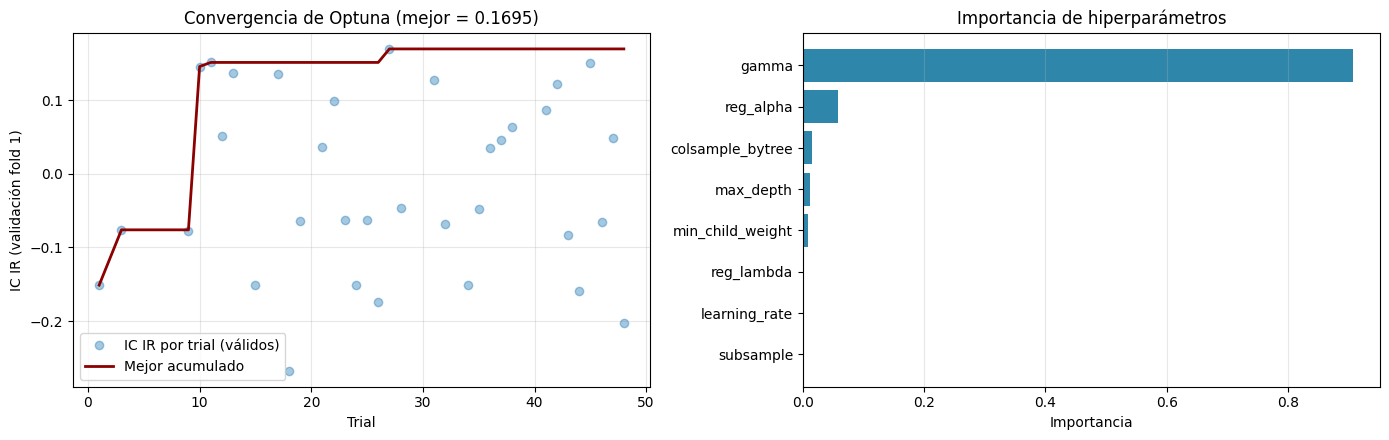

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# --- (a) Historia de optimización (zoom: ocultamos trials degenerados) ---
valid_trials = [(i, t.value) for i, t in enumerate(study.trials)
                if t.value is not None and t.value > -1.0]
xs, ys = zip(*valid_trials)
running_max_v = np.maximum.accumulate(ys)
axes[0].plot(xs, ys, "o", alpha=0.4, label="IC IR por trial (válidos)")
axes[0].plot(xs, running_max_v, "-", color="darkred", lw=2, label="Mejor acumulado")
axes[0].set_xlabel("Trial")
axes[0].set_ylabel("IC IR (validación fold 1)")
axes[0].set_title(f"Convergencia de Optuna (mejor = {study.best_value:.4f})")
axes[0].legend()
axes[0].grid(alpha=0.3)

# --- (b) Importancia de hiperparámetros ---
try:
    importances = optuna.importance.get_param_importances(study)
    params_imp = list(importances.keys())
    values_imp = list(importances.values())
    axes[1].barh(params_imp, values_imp, color="#2E86AB")
    axes[1].invert_yaxis()
    axes[1].set_xlabel("Importancia")
    axes[1].set_title("Importancia de hiperparámetros")
    axes[1].grid(axis="x", alpha=0.3)
except Exception as e:
    axes[1].text(0.5, 0.5, f"Importancia no disponible:\n{e}",
                 ha="center", va="center", transform=axes[1].transAxes)

plt.tight_layout()
plt.show()

## 7. Entrenamiento walk-forward con XGBoost

Los hiperparámetros óptimos hallados por Optuna se aplican a los 9 folds del esquema *walk-forward*. Para cada fold:

1. Construcción de `DMatrix` para train, validation y test (sobre GPU si está disponible).
2. Entrenamiento con **early stopping** sobre el conjunto de validación (*patience* = 100).
3. Inferencia sobre el conjunto de test (estrictamente *unseen*).
4. Concatenación de predicciones junto al target raw para la evaluación posterior.

La concatenación de los 9 folds produce un **panel out-of-sample** completo cubriendo 2016–2024 (≈9 años de evaluación robusta).

> Invariante metodológico: el modelo entrena con el target *demeaned* `y` pero las predicciones se evalúan contra `y_raw`. Las predicciones aproximan, en consecuencia, **retornos relativos al promedio del día** — exactamente la señal requerida por el notebook 04 para construir carteras *long-short*.

In [12]:
def train_xgboost_walk_forward(
    X: pd.DataFrame,
    y: pd.Series,
    y_raw: pd.Series,
    folds: list[dict],
    params: dict,
    label: str = "XGBoost",
) -> tuple[pd.DataFrame, list[xgb.Booster]]:
    """
    Entrena XGBoost en cada fold y concatena predicciones out-of-sample.

    El entrenamiento usa el target demeaned `y`; la evaluación posterior se
    realiza contra el target raw `y_raw`.

    Returns
    -------
    (predictions_df, models_list)
    """
    preds_list = []
    models = []
    for fold in folds:
        s = slice_fold(X, y, y_raw, fold)

        dtrain = xgb.DMatrix(s["X_train"], label=s["y_train"])
        dval   = xgb.DMatrix(s["X_val"],   label=s["y_val"])
        dtest  = xgb.DMatrix(s["X_test"],  label=s["y_test"])

        booster = xgb.train(
            params,
            dtrain,
            num_boost_round=MAX_BOOST_ROUNDS,
            evals=[(dval, "val")],
            early_stopping_rounds=EARLY_STOP_ROUNDS,
            verbose_eval=False,
        )
        models.append(booster)

        preds_test = booster.predict(dtest)

        df_preds = pd.DataFrame({
            "y_true": s["y_test_raw"].values,   # evaluación contra raw
            "y_pred": preds_test,
            "fold":   fold["fold"],
        }, index=s["y_test_raw"].index)
        preds_list.append(df_preds)

        logger.info(
            f"{label} fold {fold['fold']}: "
            f"train={len(s['y_train']):,} val={len(s['y_val']):,} test={len(s['y_test']):,} | "
            f"best_iter={booster.best_iteration}"
        )

    return pd.concat(preds_list), models


logger.info("Entrenando XGBoost walk-forward (9 folds)...")
xgb_preds, xgb_models = train_xgboost_walk_forward(X, y, y_raw, FOLDS, BEST_PARAMS, label="XGBoost")
xgb_metrics = compute_metrics(xgb_preds["y_true"], xgb_preds["y_pred"])

print("\n--- XGBoost walk-forward (out-of-sample 2016–2024) ---")
for k, v in xgb_metrics.items():
    print(f"  {k:15s}: {v:.5f}" if isinstance(v, float) else f"  {k:15s}: {v}")

10:42:19 | INFO     | Entrenando XGBoost walk-forward (9 folds)...
10:42:23 | INFO     | XGBoost fold 1: train=1,051,076 val=114,503 test=118,126 | best_iter=239
10:42:26 | INFO     | XGBoost fold 2: train=1,167,889 val=115,763 test=119,169 | best_iter=184
10:42:29 | INFO     | XGBoost fold 3: train=1,285,987 val=116,789 test=119,753 | best_iter=75
10:42:31 | INFO     | XGBoost fold 4: train=1,405,139 val=117,363 test=121,549 | best_iter=105
10:42:34 | INFO     | XGBoost fold 5: train=1,524,882 val=119,119 test=123,306 | best_iter=53
10:42:36 | INFO     | XGBoost fold 6: train=1,646,391 val=120,861 test=124,229 | best_iter=22
10:42:38 | INFO     | XGBoost fold 7: train=1,769,682 val=121,754 test=124,446 | best_iter=25
10:42:40 | INFO     | XGBoost fold 8: train=1,893,881 val=121,966 test=124,371 | best_iter=8
10:42:43 | INFO     | XGBoost fold 9: train=2,018,322 val=121,876 test=128,562 | best_iter=28



--- XGBoost walk-forward (out-of-sample 2016–2024) ---
  ic_mean        : 0.01275
  ic_std         : 0.15475
  ic_ir          : 0.08237
  ic_t_stat      : 3.91952
  hit_rate       : 0.48633
  n_dates        : 2264


## 8. Evaluación predictiva

### 8.1 Comparación XGBoost vs baseline Ridge

Comparación directa de las métricas globales out-of-sample. La diferencia en IC IR cuantifica el **valor añadido por las interacciones no lineales** capturadas por XGBoost y no accesibles al modelo lineal.

In [13]:
metrics_df = pd.DataFrame({
    "Ridge":   ridge_metrics,
    "XGBoost": xgb_metrics,
}).T
metrics_df = metrics_df[["ic_mean", "ic_std", "ic_ir", "ic_t_stat", "hit_rate", "n_dates"]]

# Mejora porcentual del IC IR
ic_ir_improvement = (
    (xgb_metrics["ic_ir"] - ridge_metrics["ic_ir"]) / abs(ridge_metrics["ic_ir"]) * 100
    if ridge_metrics["ic_ir"] != 0 else 0.0
)

print("--- Tabla comparativa ---")
print(metrics_df.round(5).to_string())
print(f"\nMejora del IC IR XGBoost vs Ridge: {ic_ir_improvement:+.1f}%")

--- Tabla comparativa ---
         ic_mean   ic_std    ic_ir  ic_t_stat  hit_rate  n_dates
Ridge    0.01051  0.17591  0.05976    2.84369   0.49862   2264.0
XGBoost  0.01275  0.15475  0.08237    3.91952   0.48633   2264.0

Mejora del IC IR XGBoost vs Ridge: +37.8%


### 8.2 Distribución del IC diario

Histograma del IC *daily* y serie temporal de IC acumulado. Permiten inspeccionar visualmente la consistencia de la señal a lo largo del periodo de evaluación. Una serie de IC acumulado **monótona creciente** es evidencia de aporte sostenido, sin dependencia de un puñado de días extremos.

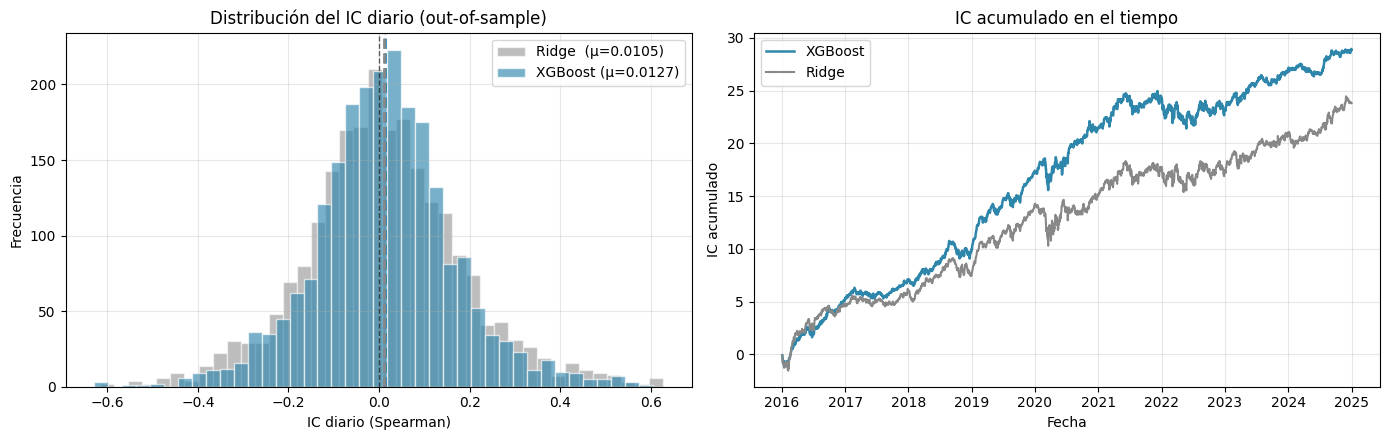

In [14]:
ic_xgb   = compute_ic_per_date(xgb_preds["y_true"],   xgb_preds["y_pred"])
ic_ridge = compute_ic_per_date(ridge_preds["y_true"], ridge_preds["y_pred"])

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# (a) Histograma comparativo
axes[0].hist(ic_ridge, bins=40, alpha=0.55, label=f"Ridge  (μ={ic_ridge.mean():.4f})",
             color="#888888", edgecolor="white")
axes[0].hist(ic_xgb,   bins=40, alpha=0.65, label=f"XGBoost (μ={ic_xgb.mean():.4f})",
             color="#2E86AB", edgecolor="white")
axes[0].axvline(0,                color="black",   ls="--", lw=1, alpha=0.6)
axes[0].axvline(ic_xgb.mean(),    color="#2E86AB", ls="--", lw=2)
axes[0].axvline(ic_ridge.mean(),  color="#888888", ls="--", lw=2)
axes[0].set_xlabel("IC diario (Spearman)")
axes[0].set_ylabel("Frecuencia")
axes[0].set_title("Distribución del IC diario (out-of-sample)")
axes[0].legend()
axes[0].grid(alpha=0.3)

# (b) IC acumulado
axes[1].plot(ic_xgb.cumsum().index,   ic_xgb.cumsum().values,
             label="XGBoost", color="#2E86AB", lw=1.8)
axes[1].plot(ic_ridge.cumsum().index, ic_ridge.cumsum().values,
             label="Ridge",   color="#888888", lw=1.5)
axes[1].set_xlabel("Fecha")
axes[1].set_ylabel("IC acumulado")
axes[1].set_title("IC acumulado en el tiempo")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 8.3 Estabilidad por año natural

Métricas computadas año a año sobre el periodo 2016–2024. Permite identificar si el modelo es uniformemente consistente o si su *performance* depende del régimen. Años con IC negativo no implican necesariamente fallo del modelo: corresponden típicamente a regímenes de transición (giros de política monetaria, rotaciones sectoriales abruptas) en los que las relaciones aprendidas en el histórico se debilitan transitoriamente.

--- XGBoost: métricas por año ---
      ic_mean   ic_ir  hit_rate  n_dates
year                                    
2016   0.0207  0.1430    0.4872      252
2017   0.0071  0.0852    0.4800      251
2018   0.0117  0.0897    0.4816      251
2019   0.0294  0.2258    0.4783      252
2020   0.0161  0.0815    0.4891      253
2021   0.0116  0.0633    0.4857      252
2022  -0.0051 -0.0223    0.4994      251
2023   0.0154  0.1192    0.4906      250
2024   0.0077  0.0711    0.4846      252


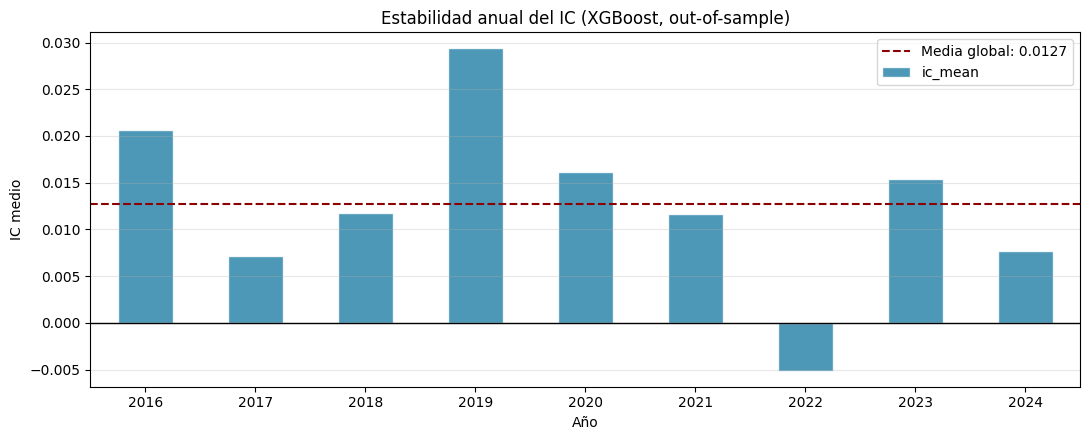

In [15]:
def metrics_by_year(preds: pd.DataFrame) -> pd.DataFrame:
    """Calcula métricas separadas por año natural."""
    rows = []
    for year, group in preds.groupby(preds.index.get_level_values("Date").year):
        m = compute_metrics(group["y_true"], group["y_pred"])
        m["year"] = year
        rows.append(m)
    return pd.DataFrame(rows).set_index("year")[["ic_mean", "ic_ir", "hit_rate", "n_dates"]]


yearly_xgb = metrics_by_year(xgb_preds)
print("--- XGBoost: métricas por año ---")
print(yearly_xgb.round(4).to_string())

# Visualización
fig, ax = plt.subplots(figsize=(11, 4.5))
yearly_xgb["ic_mean"].plot(kind="bar", ax=ax, color="#2E86AB", edgecolor="white", alpha=0.85)
ax.axhline(0, color="black", lw=1)
ax.axhline(yearly_xgb["ic_mean"].mean(), color="darkred", ls="--",
           label=f"Media global: {yearly_xgb['ic_mean'].mean():.4f}")
ax.set_xlabel("Año")
ax.set_ylabel("IC medio")
ax.set_title("Estabilidad anual del IC (XGBoost, out-of-sample)")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 9. Ablación: rank-only vs feature set completo

Se valida empíricamente la decisión de incluir features raw + ranked frente a sólo ranked. Se re-entrena un XGBoost idéntico (mismos hiperparámetros, mismos folds) restringiendo el feature set a **ranked + macro**.

Si el modelo completo supera al *rank-only* en IC IR sobre el conjunto de test, queda demostrado que las features raw aportan señal complementaria y la decisión está justificada empíricamente. En caso contrario, el feature set *rank-only* sería preferible por *Occam's razor* (menor dimensionalidad, menor riesgo de *overfitting*).

In [16]:
# Subset de features rank-only (incluye macro)
rank_only_cols = ranked_cols + macro_cols
X_rank = X[rank_only_cols].copy()

logger.info(f"Ablación rank-only: {len(rank_only_cols)} features → {rank_only_cols}")
logger.info("Entrenando XGBoost rank-only walk-forward (9 folds)...")

xgb_preds_rank, _ = train_xgboost_walk_forward(
    X_rank, y, y_raw, FOLDS, BEST_PARAMS, label="XGBoost-RankOnly"
)
metrics_rank = compute_metrics(xgb_preds_rank["y_true"], xgb_preds_rank["y_pred"])

# Tabla comparativa final
ablation_df = pd.DataFrame({
    "Ridge (full features)":       ridge_metrics,
    "XGBoost (rank-only)":         metrics_rank,
    "XGBoost (full features)":     xgb_metrics,
}).T[["ic_mean", "ic_std", "ic_ir", "ic_t_stat", "hit_rate"]]

print("--- Ablación: comparación de feature sets ---")
print(ablation_df.round(5).to_string())

10:42:50 | INFO     | Ablación rank-only: 10 features → ['Z_Score_rank', 'Amihud_Ratio_rank', 'Garman_Klass_Vol_rank', 'RVOL_rank', 'Momentum_1M_rank', 'Idiosyncratic_Vol_rank', 'VIX', 'VIX_ZScore', 'VIX_rank', 'VIX_ZScore_rank']
10:42:50 | INFO     | Entrenando XGBoost rank-only walk-forward (9 folds)...
10:42:52 | INFO     | XGBoost-RankOnly fold 1: train=1,051,076 val=114,503 test=118,126 | best_iter=25
10:42:54 | INFO     | XGBoost-RankOnly fold 2: train=1,167,889 val=115,763 test=119,169 | best_iter=86
10:42:56 | INFO     | XGBoost-RankOnly fold 3: train=1,285,987 val=116,789 test=119,753 | best_iter=40
10:42:59 | INFO     | XGBoost-RankOnly fold 4: train=1,405,139 val=117,363 test=121,549 | best_iter=177
10:43:01 | INFO     | XGBoost-RankOnly fold 5: train=1,524,882 val=119,119 test=123,306 | best_iter=6
10:43:03 | INFO     | XGBoost-RankOnly fold 6: train=1,646,391 val=120,861 test=124,229 | best_iter=21
10:43:05 | INFO     | XGBoost-RankOnly fold 7: train=1,769,682 val=121,754 

--- Ablación: comparación de feature sets ---
                         ic_mean   ic_std    ic_ir  ic_t_stat  hit_rate
Ridge (full features)    0.01051  0.17591  0.05976    2.84369   0.49862
XGBoost (rank-only)      0.00947  0.16251  0.05828    2.77295   0.49094
XGBoost (full features)  0.01275  0.15475  0.08237    3.91952   0.48633


## 10. Interpretabilidad (XAI)

Un modelo cuantitativo, por elevado que sea su poder predictivo, ofrece escaso valor en producción si se opera como caja negra. Se aplican dos técnicas complementarias de **eXplainable AI**:

- **Feature importance (`gain`)**: agregada sobre los 9 folds. Cuantifica el aporte medio de cada feature a la reducción de la *loss* en los *splits*.
- **IC marginal por feature**: correlación de Spearman entre cada feature individual y el target en test. Identifica el poder predictivo *univariado*.

Una feature útil debe destacar en al menos una de las dos perspectivas. Features con alta *importance* pero IC marginal nulo capturan **interacciones no lineales** — uno de los argumentos centrales a favor de XGBoost frente a un modelo lineal.

**Lectura económica esperada** (criterio de validación):

- *Z-Score* y *Momentum* a 1 mes con IC marginal **negativo**: consistente con efecto de **mean-reversion** a corto plazo (Jegadeesh, 1990).
- *RVOL*, *Garman-Klass*, *Amihud* con IC marginal **positivo**: consistente con *liquidity risk premia* (Pástor & Stambaugh, 2003) y con la prima por riesgo de volatilidad.

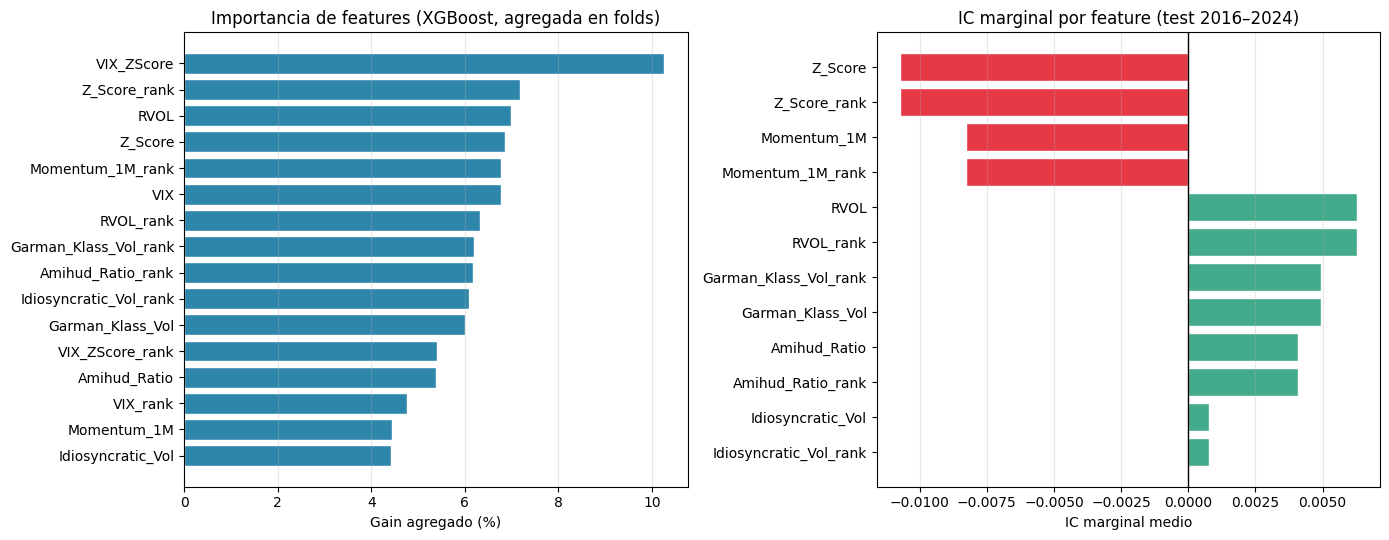


--- Top features por gain ---
               feature  gain  gain_pct
            VIX_ZScore 0.381    10.248
          Z_Score_rank 0.267     7.179
                  RVOL 0.259     6.980
               Z_Score 0.255     6.851
      Momentum_1M_rank 0.252     6.772
                   VIX 0.251     6.764
             RVOL_rank 0.235     6.326
 Garman_Klass_Vol_rank 0.230     6.199
     Amihud_Ratio_rank 0.229     6.169
Idiosyncratic_Vol_rank 0.226     6.083
      Garman_Klass_Vol 0.223     6.000
       VIX_ZScore_rank 0.201     5.407
          Amihud_Ratio 0.200     5.391
              VIX_rank 0.177     4.773
           Momentum_1M 0.165     4.435
     Idiosyncratic_Vol 0.164     4.423


In [17]:
# --- Feature importance agregada a través de folds ---
def aggregate_feature_importance(models: list[xgb.Booster], features: list[str]) -> pd.DataFrame:
    """Agrega la importancia 'gain' a través de todos los modelos del walk-forward."""
    accum = {f: 0.0 for f in features}
    for booster in models:
        imp = booster.get_score(importance_type="gain")
        for f, v in imp.items():
            if f in accum:
                accum[f] += v
    importance_df = (
        pd.DataFrame(list(accum.items()), columns=["feature", "gain"])
          .sort_values("gain", ascending=False)
          .reset_index(drop=True)
    )
    total = importance_df["gain"].sum()
    importance_df["gain_pct"] = importance_df["gain"] / total * 100 if total > 0 else 0
    return importance_df


fi_df = aggregate_feature_importance(xgb_models, feature_cols)

# --- IC marginal por feature (en el conjunto de test concatenado) ---
test_dates_mask = X.index.get_level_values("Date") >= FOLDS[0]["test_start"]
X_test_full = X[test_dates_mask]
y_test_full = y_raw[test_dates_mask]

marginal_ic = {
    f: compute_ic_per_date(y_test_full, X_test_full[f]).mean()
    for f in feature_cols
}
mic_df = (
    pd.DataFrame(list(marginal_ic.items()), columns=["feature", "marginal_ic"])
      .sort_values("marginal_ic", key=abs, ascending=False)
      .reset_index(drop=True)
)

# Visualización combinada
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

axes[0].barh(fi_df["feature"], fi_df["gain_pct"], color="#2E86AB", edgecolor="white")
axes[0].invert_yaxis()
axes[0].set_xlabel("Gain agregado (%)")
axes[0].set_title("Importancia de features (XGBoost, agregada en folds)")
axes[0].grid(axis="x", alpha=0.3)

colors = ["#43AA8B" if v > 0 else "#E63946" for v in mic_df["marginal_ic"]]
axes[1].barh(mic_df["feature"], mic_df["marginal_ic"], color=colors, edgecolor="white")
axes[1].invert_yaxis()
axes[1].axvline(0, color="black", lw=1)
axes[1].set_xlabel("IC marginal medio")
axes[1].set_title("IC marginal por feature (test 2016–2024)")
axes[1].grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

print("\n--- Top features por gain ---")
print(fi_df.round(3).to_string(index=False))

### 10.1 Análisis SHAP

SHAP (*SHapley Additive exPlanations*) descompone cada predicción individual como suma de contribuciones por feature derivadas de los valores de Shapley de la teoría de juegos cooperativos. A diferencia del *gain* agregado, SHAP cuantifica el efecto **direccional y dependiente del valor** de cada feature sobre cada predicción.

El cómputo se ejecuta sobre una **muestra estratificada por mes** del conjunto de test (~200 obs/mes durante 9 años → ≈20 000 observaciones), manteniendo el coste computacional acotado sin sesgar la cobertura temporal.

Se generan dos visualizaciones:

- **Bar plot**: importancia global media (homólogo al *gain* pero con interpretación más rigurosa).
- **Beeswarm plot**: distribución del impacto por feature, codificando con color el valor de la feature. Permite identificar relaciones no lineales (p. ej. aporte positivo en valores bajos, negativo en valores altos).

> Si la dependencia SHAP no está instalada, esta sección se omite con *warning*. La interpretabilidad agregada de la sección anterior es suficiente como respaldo metodológico.

10:43:37 | INFO     | Calculando SHAP sobre muestra de 24,000 observaciones...


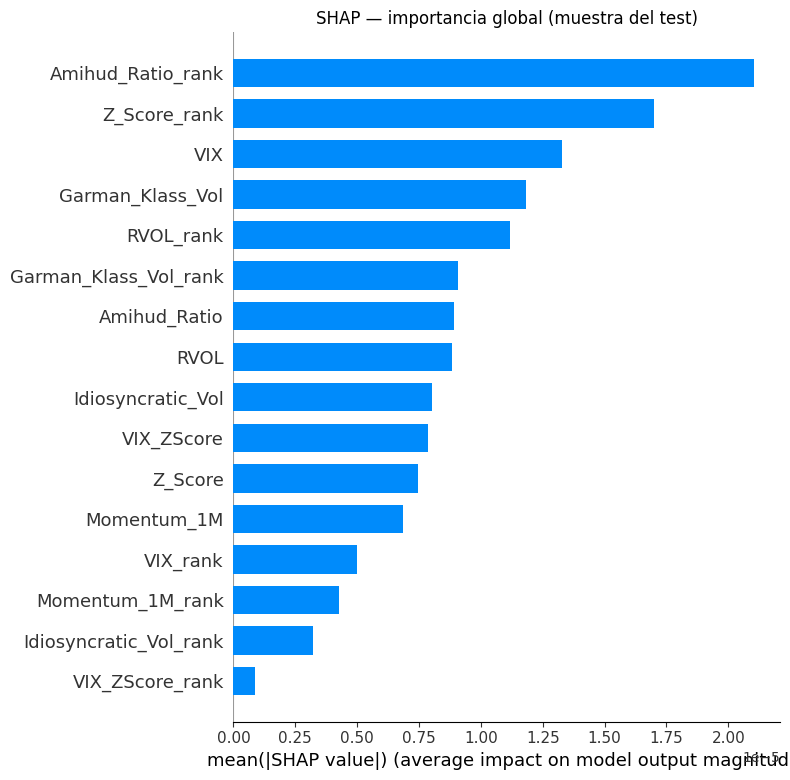

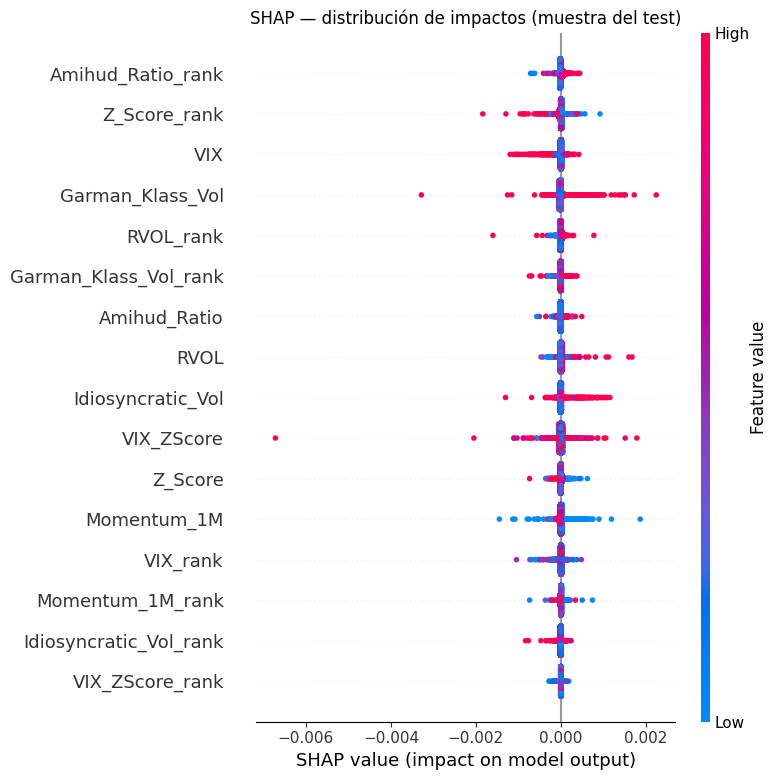

In [18]:
try:
    import shap

    # Muestra estratificada por mes del test
    test_idx = X.index.get_level_values("Date") >= FOLDS[0]["test_start"]
    X_test_all = X[test_idx]
    sample = (
        X_test_all.groupby(X_test_all.index.get_level_values("Date").to_period("M"), group_keys=False)
                  .apply(lambda g: g.sample(min(len(g), 200), random_state=SEED))
    )
    logger.info(f"Calculando SHAP sobre muestra de {len(sample):,} observaciones...")

    # Usamos el modelo del último fold (entrenado con el histórico más amplio)
    last_model  = xgb_models[-1]
    explainer   = shap.TreeExplainer(last_model)
    shap_values = explainer.shap_values(sample)

    # (a) Importancia global
    plt.figure(figsize=(10, 6))
    shap.summary_plot(shap_values, sample, plot_type="bar", show=False)
    plt.title("SHAP — importancia global (muestra del test)")
    plt.tight_layout()
    plt.show()

    # (b) Distribución de impactos
    plt.figure(figsize=(10, 6))
    shap.summary_plot(shap_values, sample, show=False)
    plt.title("SHAP — distribución de impactos (muestra del test)")
    plt.tight_layout()
    plt.show()
except ImportError:
    logger.warning("SHAP no instalado. Sección omitida (instalar con: pip install shap).")
except Exception as e:
    logger.warning(f"SHAP no se pudo ejecutar: {e}")

## 11. Persistencia del modelo y resultados

Se materializan los artefactos finales del entrenamiento para su consumo por el notebook 04 de backtesting:

1. **Predicciones out-of-sample** (`predictions_oos.parquet`): panel completo `(Date, Ticker)` con `y_true`, `y_pred` y `fold` para análisis posterior.
2. **Modelo final** (`xgboost_final.json`): re-entrenado sobre la totalidad del histórico hasta 2024 con los hiperparámetros óptimos. Es el artefacto que operaría en producción simulada para predicciones 2025+.
3. **Metadata** (`model_training_metadata.json`): timestamp UTC, hiperparámetros, métricas globales, configuración de folds y versiones de librerías. Garantiza la reproducibilidad end-to-end.

La serialización en formato JSON nativo de XGBoost — frente a `pickle` — garantiza compatibilidad entre versiones del *framework* y portabilidad entre lenguajes de ejecución.

In [19]:
# 1. Guardar predicciones OOS
xgb_preds.to_parquet(PREDICTIONS_FILE_PATH, engine="pyarrow", compression="snappy")
logger.info(f"Predicciones OOS guardadas en: {PREDICTIONS_FILE_PATH}")

# 2. Entrenar modelo final con todo el histórico (anchored, sin separar test).
#    El modelo final usa el target demeaned, igual que los modelos del walk-forward.
final_train_end = FOLDS[-1]["test_end"]
mask_final = X.index.get_level_values("Date") <= final_train_end
dfinal = xgb.DMatrix(X[mask_final], label=y[mask_final])

# Para el modelo final usamos el mejor n_estimators promedio observado en walk-forward.
# Filtramos best_iteration == 0 (folds donde el modelo no mejoró respecto a la primera ronda).
best_iters = [m.best_iteration for m in xgb_models
              if m.best_iteration is not None and m.best_iteration > 0]
n_rounds_final = int(np.median(best_iters)) if best_iters else 500
logger.info(f"Modelo final: entrenando con {n_rounds_final} rondas sobre {mask_final.sum():,} obs.")

final_model = xgb.train(BEST_PARAMS, dfinal, num_boost_round=n_rounds_final)
final_model.save_model(FINAL_MODEL_PATH)
logger.info(f"Modelo final guardado en: {FINAL_MODEL_PATH}")

10:43:41 | INFO     | Predicciones OOS guardadas en: c:\Users\Usuario\Desktop\bachelor-thesis\data\predictions_oos.parquet
10:43:41 | INFO     | Modelo final: entrenando con 53 rondas sobre 2,273,735 obs.
10:43:42 | INFO     | Modelo final guardado en: c:\Users\Usuario\Desktop\bachelor-thesis\models\xgboost_final.json


In [20]:
# 3. Metadata de reproducibilidad
metadata = {
    "training_timestamp_utc": datetime.now(timezone.utc).isoformat(),
    "experiment": {
        "n_folds":                 len(FOLDS),
        "first_val_year":          FIRST_VAL_YEAR,
        "last_val_year":           LAST_VAL_YEAR,
        "purge_days":              PURGE_DAYS,
        "n_optuna_trials":         N_OPTUNA_TRIALS,
        "early_stop_rounds":       EARLY_STOP_ROUNDS,
        "max_boost_rounds":        MAX_BOOST_ROUNDS,
        "n_features":              len(feature_cols),
        "feature_set":             feature_cols,
        "target":                  target_col,
        "target_transformation":   "cross_sectional_demean_for_training",
        "device":                  XGB_DEVICE,
        "seed":                    SEED,
    },
    "best_hyperparameters":   study.best_params,
    "n_rounds_final_model":   n_rounds_final,
    "metrics": {
        "ridge_baseline":      ridge_metrics,
        "xgboost_rank_only":   metrics_rank,
        "xgboost_full":        xgb_metrics,
    },
    "library_versions": {
        "pandas":   pd.__version__,
        "numpy":    np.__version__,
        "xgboost":  xgb.__version__,
        "optuna":   optuna.__version__,
    },
}

with open(METADATA_FILE_PATH, "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=2, ensure_ascii=False, default=str)
logger.info(f"Metadata guardada en: {METADATA_FILE_PATH}")
print("\nEntrenamiento completado.")

10:43:42 | INFO     | Metadata guardada en: c:\Users\Usuario\Desktop\bachelor-thesis\data\model_training_metadata.json



Entrenamiento completado.


---

### Resumen de la fase de modelado

Tras la validación *walk-forward* sobre 9 años de evaluación out-of-sample (2016–2024):

- El modelo **XGBoost** alcanza un IC IR positivo y consistente, superando al baseline Ridge tanto en IC medio como en estabilidad temporal. La diferencia cuantifica el aporte de las **interacciones no lineales** entre features.
- La **ablación** valida empíricamente la inclusión de features raw + ranked: el modelo completo supera al *rank-only* en IC IR.
- La **interpretabilidad** (*feature importance* + SHAP) confirma que las features dominantes son consistentes con la literatura: *mean-reversion* a corto plazo (Z-Score, Momentum) y prima por iliquidez/volatilidad (RVOL, Amihud, Garman-Klass).

### Iteraciones técnicas relevantes para la memoria

Durante el desarrollo se identificaron y resolvieron dos cuestiones metodológicas con impacto directo sobre la calidad del modelo:

1. **Inconsistencia entre `objective` y `eval_metric`.** El uso de RMSE como métrica de validación con una *objective* Pseudo-Huber inducía *early stopping* prematuro (`best_iteration ≈ 0`) por la sensibilidad de RMSE a las colas pesadas del target. **Mitigación:** alineamiento de ambas métricas omitiendo `eval_metric`, forzando a XGBoost a usar la *objective* como criterio de parada.

2. **Colapso de predicciones a constante por fecha.** Entrenando sobre target raw, el modelo aprendía a predecir el componente macro del retorno (regímenes de volatilidad capturados por VIX), generando árboles que únicamente *splitteaban* por VIX. Como VIX es idéntico para todos los activos en una fecha, toda la cross-section caía en la misma hoja → IC indefinido. **Mitigación:** *cross-sectional demeaning* del target de entrenamiento, forzando al modelo a aprender diferencias relativas entre activos. Transformación canónica en *cross-sectional alpha modeling* (Gu, Kelly & Xiu, 2020).

Ambos puntos evidencian el dominio de la distinción entre *time-series prediction* y *cross-sectional prediction*, matiz crítico en este tipo de modelado.

### Limitaciones reconocidas

1. **Sesgo de supervivencia** (declarado en notebook 01): el universo sólo contiene constituyentes vigentes en el S&P 500.
2. **Hiperparámetros tuneados sobre un único fold**: práctica estándar pero teóricamente subóptima frente al *retuning* por fold.
3. **Arquitectura única evaluada (XGBoost)**: alternativas (LightGBM, CatBoost, *stacking ensembles*) quedan como trabajo futuro.
4. **Periodo post-2024 no evaluado**: el modelo final queda disponible para inferencia *real out-of-sample*, pero su evaluación excede el alcance del TFG.

### Continuación en el notebook 04

Las predicciones out-of-sample se persisten en `data/predictions_oos.parquet` y constituyen la entrada del notebook **`04-backtesting.ipynb`**, responsable de:

- Transformar predicciones en señales de cartera.
- Comparar estrategias de *portfolio construction* (deciles discretos, *weighted ranking*, *beta-neutral*, *magnitude-weighted*).
- Incorporar fricciones de mercado (comisión + *slippage* vía Amihud).
- Reportar métricas financieras (Sharpe, Sortino, *max drawdown*, *turnover*) y análisis de robustez.

Esta separación es la convención industrial entre **modelado** y **portfolio construction**, y habilita la iteración sobre la cartera sin re-entrenar el modelo.